In [2]:
import torch
import numpy as np
import yfinance as yf
import pandas as pd
from operator import itemgetter
from models.lstm_model import LSTM_Model
from utils import get_device, build_seq, plus_bus_day, get_yf_data, plot_stock_price

# Parameter

In [3]:
ckpt_path = '../checkpoints/lstm_checkpoint.pt'
ticker = 'VOO'

# Extract saved objects and configs

In [4]:
device = get_device()
checkpoint = torch.load( ckpt_path , map_location = device)

In [5]:
model_config = checkpoint["model_config"]
x_scaler = checkpoint["x_scaler"]
y_scaler = checkpoint["y_scaler"]
input_cols = checkpoint["input_cols"]
seq_len = checkpoint["preprocess_config"]["seq_length"]
steps_ahead = checkpoint["steps_ahead"]
target_cols = checkpoint['target_cols']

# Rebuild model

In [6]:
model = LSTM_Model(**model_config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
_ = model.eval()

# Get Latest Data

In [7]:
data = get_yf_data( ticker , '2025-06-01' )

[*********************100%***********************]  1 of 1 completed


# Prepare Data

In [8]:
X_latest = x_scaler.transform(data[input_cols].values)
y_latest = y_scaler.transform(data[target_cols].values)

In [9]:
Date_all = data['Date'].values.flatten().tolist()
Seqs = build_seq( seq_len, X_latest, steps_ahead, Date_all, y_latest, True)
X_seq, X_Dates, y_Seq = itemgetter('X_Seq','X_id','y_Seq')(Seqs)

In [10]:
Result_list = []

for id, item in enumerate(X_Dates):
    
    fr = item[0].strftime('%Y-%m-%d')
    to = item[-1].strftime('%Y-%m-%d')

    actual = y_scaler.inverse_transform([y_Seq[id]])[0, 0] if y_Seq[id] is not None else None
    
    predict_day = plus_bus_day(to, steps_ahead)

    predict_seq = X_seq[id]
    Predict_Tensor = torch.tensor(predict_seq, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        
        pred_scaled = model(Predict_Tensor).cpu().numpy()    
        pred_real = y_scaler.inverse_transform(pred_scaled)[0, 0]


    result = {
                "Ref_From" : fr,
                "Ref_To" : to,
                "Date": predict_day,
                "Actual": round(actual,3) if actual is not None else None, 
                "Predict": round(pred_real,3),
                "Difference": round(pred_real - actual,3) if actual is not None else None,       
             }
    
    Result_list.append(result)


In [11]:
df_result = pd.DataFrame(Result_list)

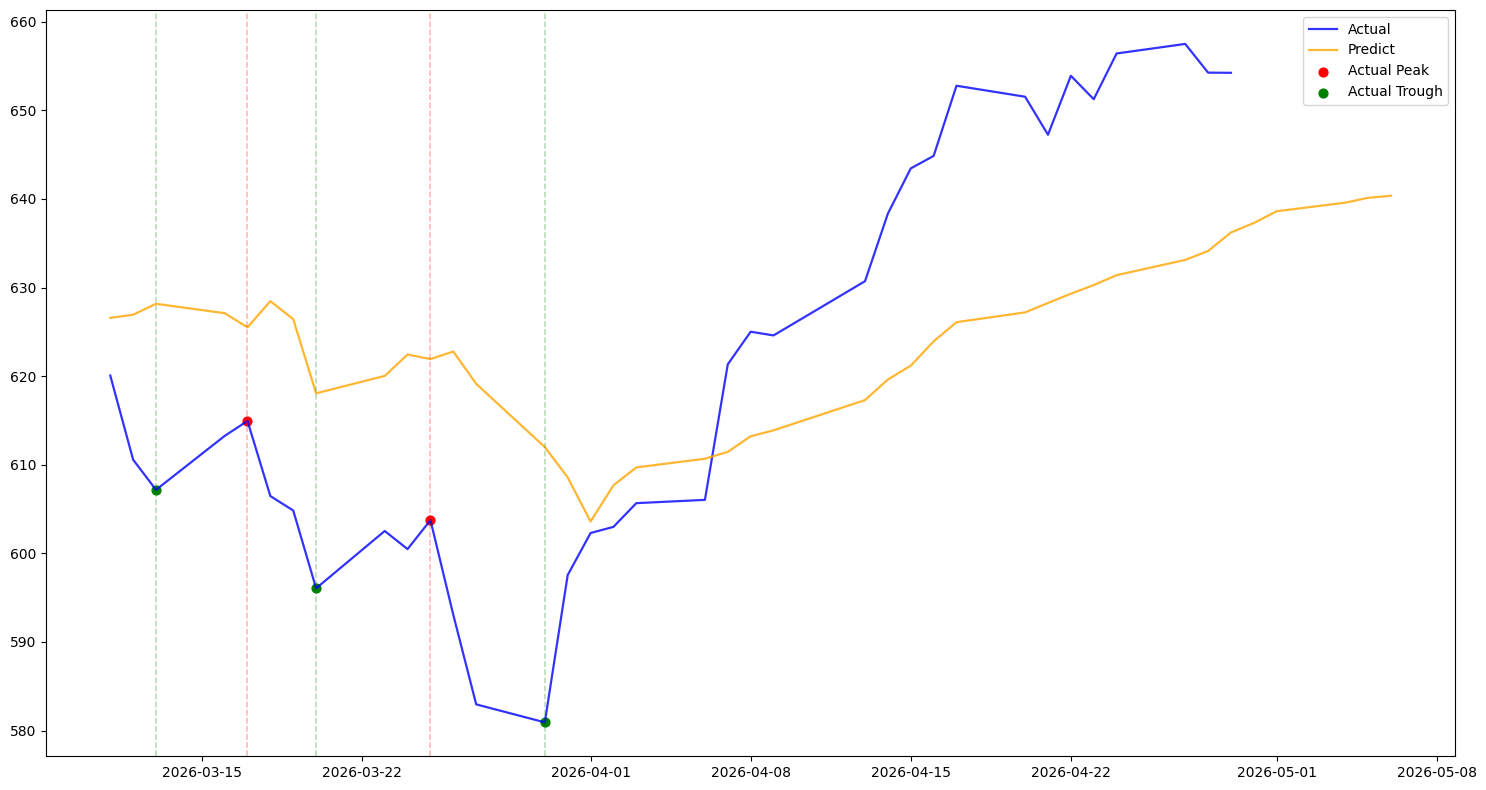

In [15]:
plot_stock_price(df_result, 'Date', ('Actual','Predict') , 'Actual', 6.0, 40)